In [ ]:
# Install system dependencies
!apt-get update
!apt-get install -y git cmake make build-essential

!rm -rf GPUZIP/
!git clone https://github.com/LSC-Unicamp/GPUZIP.git
!cd GPUZIP/GPUZIPy && pip install .

Hit:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:2 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:3 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:4 https://cli.github.com/packages stable InRelease
Hit:5 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:8 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:10 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading packag

Constants & Imports

In [46]:
"""Round-trip compression: compress with cuZFP/Bitcomp, decompress,
and report PSNR, SSIM, and the achieved compression rate."""
import urllib.request
import zipfile
from pathlib import Path
from IPython.display import Image, display

import cupy as cp
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
from skimage.metrics import structural_similarity

from gpuzipy import (
    CompressorBitcomp,
    CompressorZFP,
    compress,
    compressed_buffer_max_size,
    compressed_buffer_size,
    decompress,
)

CUZFP = 0
BITCOMP = 1

DATA_DIR = Path('/data')
MARMOUSI3D_URL = 'https://redu.unicamp.br/api/access/datafile/13547?gbrecs=true'
MARMOUSI3D_ARCHIVE = DATA_DIR / 'marmousi3d.bin.zipfile'
MARMOUSI3D_BIN = DATA_DIR / 'marmousi3d.bin'
MARMOUSI3D_N1, MARMOUSI3D_N2, MARMOUSI3D_N3 = 351, 901, 301
MARMOUSI3D_SHAPE = (MARMOUSI3D_N3, MARMOUSI3D_N2, MARMOUSI3D_N1)

OUTPUT_DIR = Path('./output')

## Downloading the data for tests (Marmousi-3D)

In [47]:
def download_marmousi3d():
    """Download (if needed) and load the Marmousi3D velocity model as a float32 array."""
    DATA_DIR.mkdir(exist_ok=True)

    if not MARMOUSI3D_ARCHIVE.exists():
        print(f'Downloading {MARMOUSI3D_URL}')
        urllib.request.urlretrieve(MARMOUSI3D_URL, MARMOUSI3D_ARCHIVE)

    if not MARMOUSI3D_BIN.exists():
        with zipfile.ZipFile(MARMOUSI3D_ARCHIVE) as archive:
            archive.extract(MARMOUSI3D_BIN.name, DATA_DIR)

    return np.fromfile(MARMOUSI3D_BIN, dtype=np.float32).reshape(MARMOUSI3D_SHAPE)


data = download_marmousi3d()
print('Loaded Marmousi3D:', data.shape, data.dtype)

Loaded Marmousi3D: (301, 901, 351) float32


Displaying a slide of the downloaded (3D) data

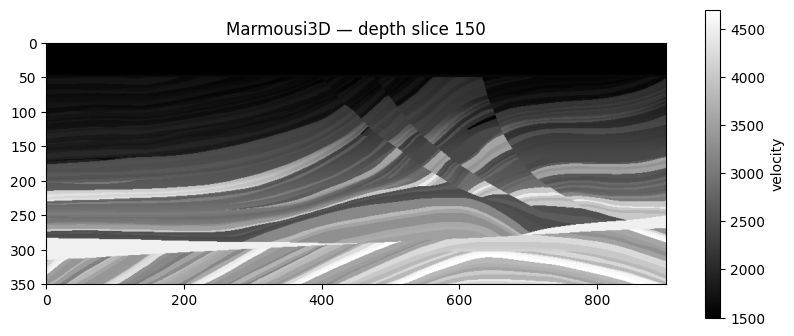

In [49]:
mid = data.shape[0] // 2
plt.figure(figsize=(10, 4))
plt.gca().invert_yaxis()
plt.imshow(data[mid].T, cmap='gray')
plt.title(f'Marmousi3D — depth slice {mid}')
plt.colorbar(label='velocity')
plt.show()

## Quality Metrics

In [50]:
def psnr(reference, test):
    """Peak signal-to-noise ratio (dB) between two same-shaped float arrays."""
    mse = np.mean((reference - test) ** 2)
    if mse == 0:
        raise ValueError('Oops, MSE == 0')
    return 20 * np.log10(255 / np.sqrt(mse))


def ssim(reference, test):
    """Average structural similarity (SSIM) across depth slices of two 3D arrays."""
    data_range = reference.max() - reference.min()
    scores = [
        structural_similarity(reference[i], test[i], data_range=data_range)
        for i in range(reference.shape[0])
    ]
    return float(np.mean(scores))

## Rendering helpers

In [51]:
def save_slice_image(frame, path, cmap='gray', colorbar=False, title=None):
    """Save a 2D array as an image."""
    plt.figure()
    plt.gca().invert_yaxis()
    im = plt.imshow(frame, cmap=cmap)
    if colorbar:
        plt.colorbar(im)
    if title:
        plt.title(title)
    plt.savefig(path, bbox_inches='tight', dpi=150)
    plt.close()


def show_comparison(name, original, decompressed, psnr_value, ssim_value):
    mid = original.shape[0] // 2
    orig = original[mid].T
    dec = decompressed[mid].T
    err = np.abs(orig - dec)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax in axes:
        ax.invert_yaxis()

    axes[0].imshow(orig, cmap='gray')
    axes[0].set_title(f'{name} — original')
    axes[1].imshow(dec, cmap='gray')
    axes[1].set_title(f'{name} — decompressed')
    im = axes[2].imshow(err, cmap='viridis')
    axes[2].set_title(f'PSNR {psnr_value:.2f} dB | SSIM {ssim_value:.4f}')
    fig.colorbar(im, ax=axes[2], fraction=0.046)

    plt.tight_layout()
    plt.show()

## The compress/decompress round-trip with GPUZIP

In [52]:
def test_compression(h_uncompressed, config, name):
    """Compress/decompress per `config`, returning (psnr, ssim, compression_rate)."""
    print('Compressing with', config)
    n1, n2, n3 = h_uncompressed.shape

    compressor = None
    if config['compressor'] == BITCOMP:
        config_kind = 2  # STATIC_DELTA
        compressor = CompressorBitcomp(
            n1, n2, n3, config_kind, 0.0, 0.0, config['delta'], 'float', 'default')
    elif config['compressor'] == CUZFP:
        compressor = CompressorZFP(n1, n2, n3, 'float', config['rate'])

    d_uncompressed = cp.asarray(h_uncompressed)

    estimated_size = compressed_buffer_max_size(compressor)
    d_compressed_ptr = cp.cuda.malloc_async(estimated_size)
    d_decompressed = cp.empty((n1, n2, n3), dtype=np.float32)

    compress(compressor, d_uncompressed.data.ptr, d_compressed_ptr.ptr)
    actual_size = compressed_buffer_size(compressor, d_compressed_ptr.ptr)
    decompress(compressor, d_compressed_ptr.ptr, d_decompressed.data.ptr)

    compression_rate = d_decompressed.nbytes / actual_size

    h_decompressed = d_decompressed.get()
    psnr_value = psnr(h_uncompressed, h_decompressed)
    ssim_value = ssim(h_uncompressed, h_decompressed)
    show_comparison(name, h_uncompressed, h_decompressed, psnr_value, ssim_value)

    return psnr_value, ssim_value, compression_rate

## Compressing with cuZFP

Compressing with {'rate': 16, 'compressor': 0}


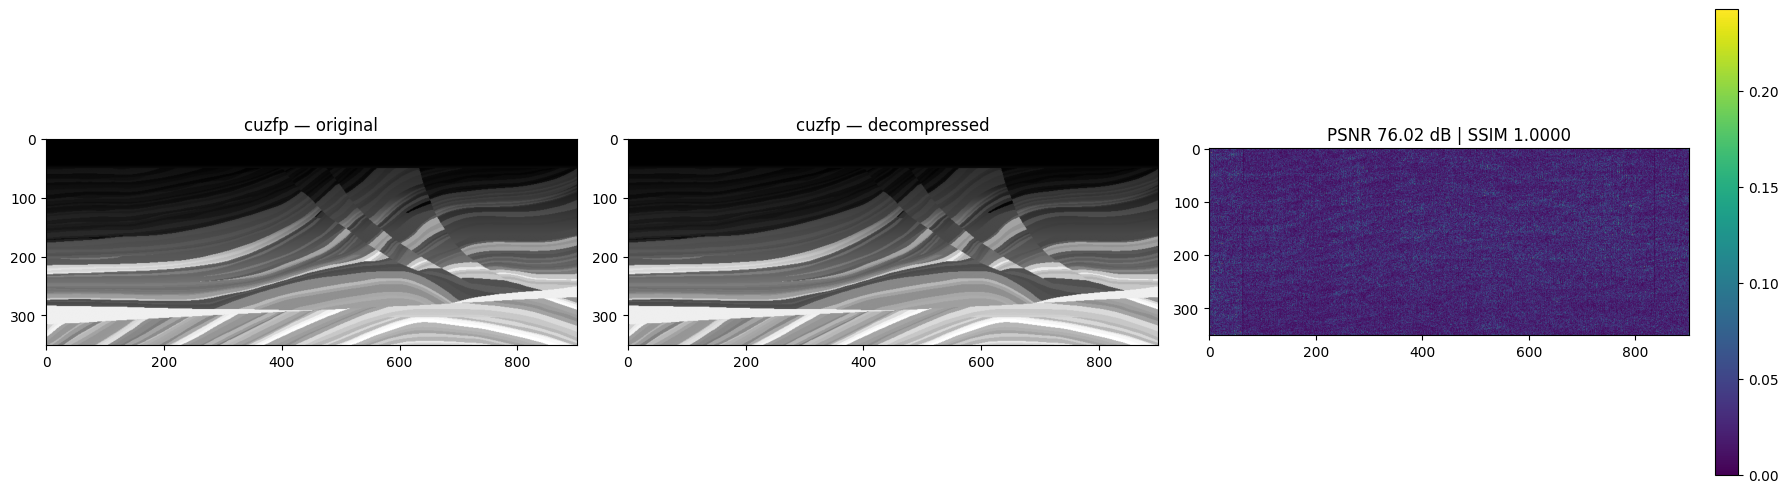

cuZFP  → psnr: 76.021545 ssim: 1.0000016889733616 rate: 1.9680841658909756


In [53]:
psnr_value, ssim_value, compression_rate = test_compression(
    data, {'rate': 16, 'compressor': CUZFP}, 'cuzfp')
print('cuZFP  → psnr:', psnr_value, 'ssim:', ssim_value, 'rate:', compression_rate)

## Compressing with Bitcomp

Compressing with {'delta': 0.01, 'compressor': 1}


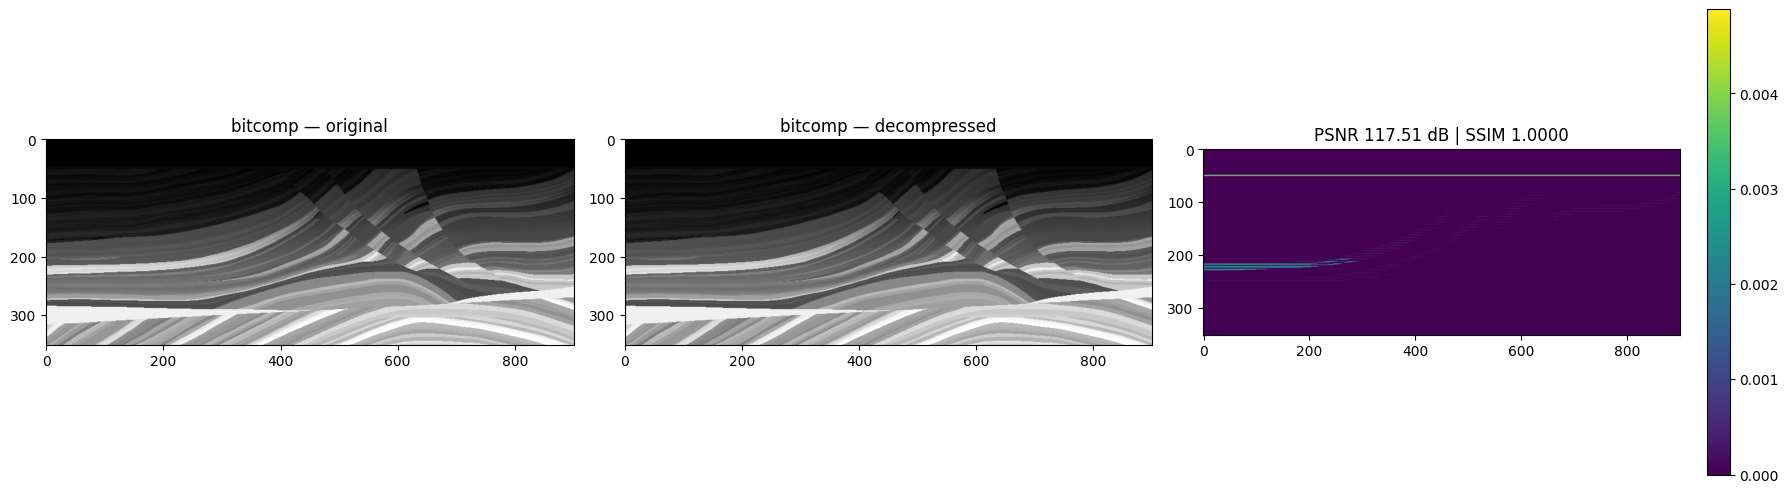

Bitcomp → psnr: 117.514206 ssim: 1.0000001148794955 rate: 2.25231197157065


In [54]:
psnr_value, ssim_value, compression_rate = test_compression(
    data, {'delta': 1e-2, 'compressor': BITCOMP}, 'bitcomp')
print('Bitcomp → psnr:', psnr_value, 'ssim:', ssim_value, 'rate:', compression_rate)